<h1><center>Xây dựng mô hình Random Forest cho bài toán phân loại thuốc</center></h1>

Giả sử bạn là một người nghiên cứu về dữ liệu y học, bạn đã thu thập được một tập dữ liệu các bệnh nhân của cùng một loại bệnh, trong khi điều trị mỗi bệnh nhân phản ứng với 1 trong 5 loại thuốc: drugA, drugB, drugC, drugX và drugY.

Công việc cần làm là xây dựng một mô hình nhằm tìm ra loại thuốc phù hợp cho bệnh nhân mới. Bài thực hành này sử dụng **Random Forest** làm mô hình chính, kết hợp tối ưu siêu tham số bằng **GridSearchCV** và so sánh với các mô hình khác.

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <h2>Nội dung thực hành</h2>
    <ol>
        <li>Import thư viện</li>
        <li>Giới thiệu và tải dữ liệu</li>
        <li>Tiền xử lý dữ liệu</li>
        <li>Cài đặt mô hình Random Forest</li>
        <li>Huấn luyện</li>
        <li>Dự đoán</li>
        <li>Đánh giá mô hình</li>
        <li>Đánh giá ảnh hưởng của các thuộc tính với nhãn</li>
        <li>Lựa chọn tối ưu tham số</li>
        <li>So sánh các mô hình</li>
    </ol>
</div>

---
## 1. Import thư viện

Import các thư viện cần thiết:
- **numpy, pandas** — xử lý dữ liệu
- **matplotlib, seaborn** — trực quan hoá
- **sklearn** — xây dựng và đánh giá mô hình

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn import preprocessing, metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

print('Tất cả thư viện đã được import thành công.')

Tất cả thư viện đã được import thành công.


---
## 2. Giới thiệu và tải dữ liệu

Tập dữ liệu **drug200.csv** gồm 200 bệnh nhân với các thuộc tính:

| Thuộc tính | Mô tả |
|---|---|
| Age | Tuổi bệnh nhân |
| Sex | Giới tính (F / M) |
| BP | Huyết áp (LOW / NORMAL / HIGH) |
| Cholesterol | Mức cholesterol (NORMAL / HIGH) |
| Na_to_K | Tỉ lệ natri / kali trong máu |
| **Drug** | **Loại thuốc phản hồi — nhãn cần dự đoán** |

In [2]:
my_data = pd.read_csv('drug200.csv', delimiter=',')
print(f'Kích thước dữ liệu: {my_data.shape}')
my_data.head()

Kích thước dữ liệu: (200, 6)


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [3]:
print('Thông tin tổng quan:')
my_data.info()
print('\nSố giá trị null theo từng cột:')
print(my_data.isnull().sum())
print('\nPhân phối nhãn (Drug):')
print(my_data['Drug'].value_counts())

Thông tin tổng quan:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 9.5 KB

Số giá trị null theo từng cột:
Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

Phân phối nhãn (Drug):
Drug
drugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


### Khám phá dữ liệu

Trực quan hoá phân phối một số thuộc tính quan trọng trước khi xây dựng mô hình.

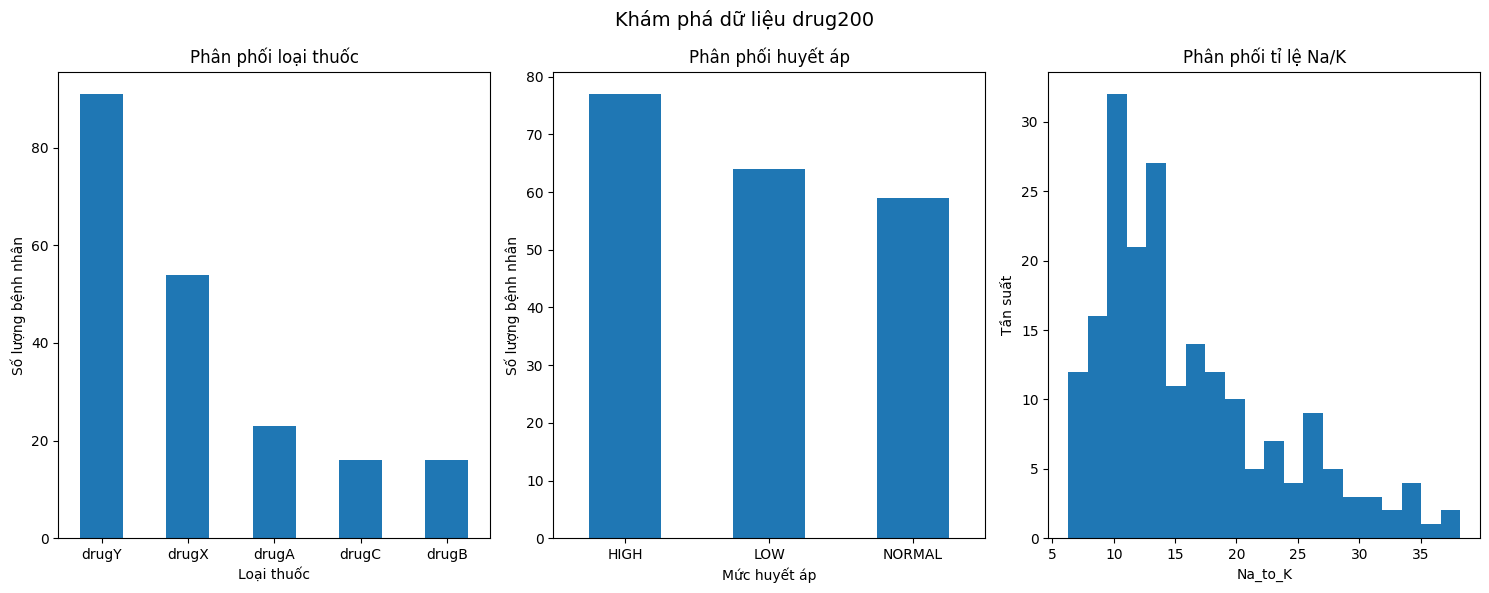

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

my_data['Drug'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Phân phối loại thuốc')
axes[0].set_xlabel('Loại thuốc')
axes[0].set_ylabel('Số lượng bệnh nhân')
axes[0].tick_params(axis='x', rotation=0)

my_data['BP'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Phân phối huyết áp')
axes[1].set_xlabel('Mức huyết áp')
axes[1].set_ylabel('Số lượng bệnh nhân')
axes[1].tick_params(axis='x', rotation=0)

axes[2].hist(my_data['Na_to_K'], bins=20)
axes[2].set_title('Phân phối tỉ lệ Na/K')
axes[2].set_xlabel('Na_to_K')
axes[2].set_ylabel('Tần suất')

plt.suptitle('Khám phá dữ liệu drug200', fontsize=14)
plt.tight_layout()
plt.show()

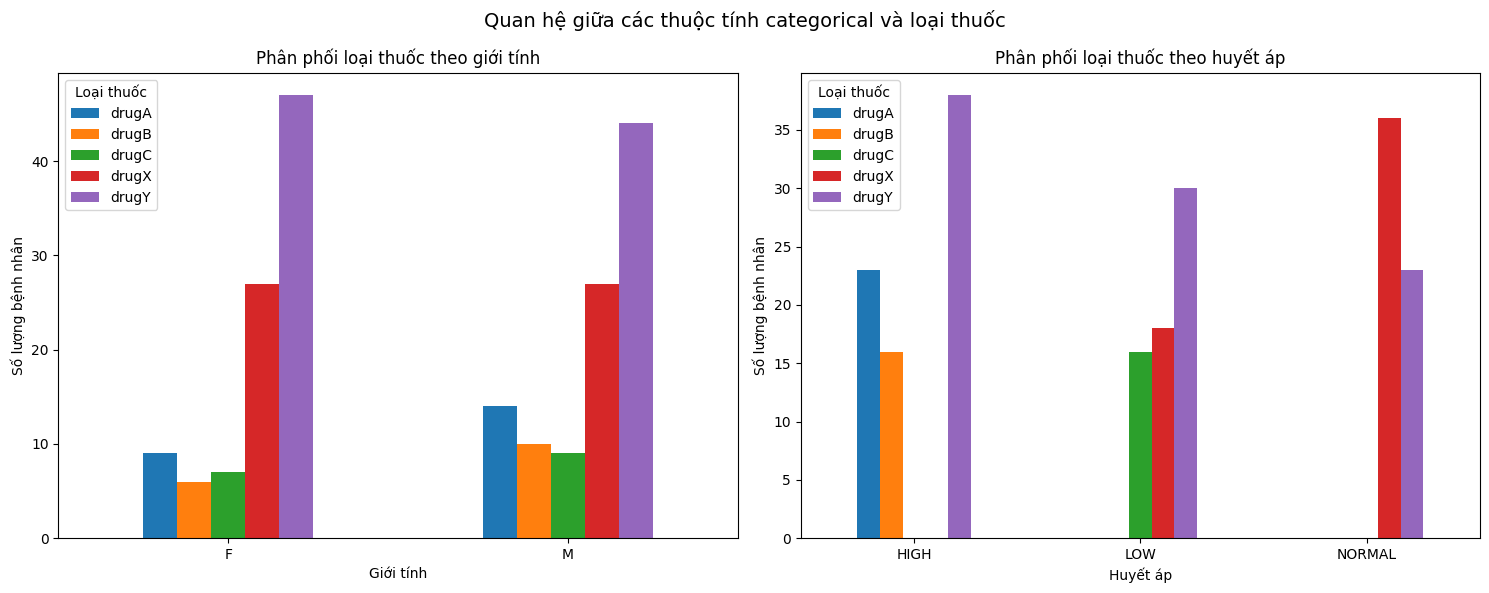

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

pd.crosstab(my_data['Sex'], my_data['Drug']).plot(kind='bar', ax=axes[0])
axes[0].set_title('Phân phối loại thuốc theo giới tính')
axes[0].set_xlabel('Giới tính')
axes[0].set_ylabel('Số lượng bệnh nhân')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Loại thuốc')

pd.crosstab(my_data['BP'], my_data['Drug']).plot(kind='bar', ax=axes[1])
axes[1].set_title('Phân phối loại thuốc theo huyết áp')
axes[1].set_xlabel('Huyết áp')
axes[1].set_ylabel('Số lượng bệnh nhân')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Loại thuốc')

plt.suptitle('Quan hệ giữa các thuộc tính categorical và loại thuốc', fontsize=14)
plt.tight_layout()
plt.show()

---
## 3. Tiền xử lý dữ liệu

Mô hình Random Forest trong sklearn chỉ xử lý dữ liệu số. Do đó cần chuyển các thuộc tính dạng categorical (Sex, BP, Cholesterol) về dạng số nguyên bằng `LabelEncoder`.

In [6]:
X = my_data[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']].values

le_sex = preprocessing.LabelEncoder()
le_sex.fit(['F', 'M'])
X[:, 1] = le_sex.transform(X[:, 1])

le_BP = preprocessing.LabelEncoder()
le_BP.fit(['LOW', 'NORMAL', 'HIGH'])
X[:, 2] = le_BP.transform(X[:, 2])

le_Chol = preprocessing.LabelEncoder()
le_Chol.fit(['NORMAL', 'HIGH'])
X[:, 3] = le_Chol.transform(X[:, 3])

y = my_data['Drug']

print('Ma trận thuộc tính X sau khi mã hoá (5 mẫu đầu):')
print(X[0:5])

Ma trận thuộc tính X sau khi mã hoá (5 mẫu đầu):
[[23 0 0 0 25.355]
 [47 1 1 0 13.093]
 [47 1 1 0 10.114]
 [28 0 2 0 7.798]
 [61 0 1 0 18.043]]


Chia dữ liệu thành tập **train (70%)** dùng để huấn luyện và tập **test (30%)** dùng để đánh giá.

In [7]:
X_trainset, X_testset, y_trainset, y_testset = train_test_split(
    X, y, test_size=0.3, random_state=3
)

In [8]:
print('Kích thước tập train:')
print('X_trainset:', X_trainset.shape)
print('y_trainset:', y_trainset.shape)

Kích thước tập train:
X_trainset: (140, 5)
y_trainset: (140,)


In [9]:
print('Kích thước tập test:')
print('X_testset:', X_testset.shape)
print('y_testset:', y_testset.shape)

Kích thước tập test:
X_testset: (60, 5)
y_testset: (60,)


---
## 4. Cài đặt mô hình Random Forest

Tạo đối tượng `RandomForestClassifier` với 100 cây quyết định (`n_estimators=100`). Random Forest xây dựng nhiều cây độc lập trên các tập con ngẫu nhiên của dữ liệu và kết hợp kết quả bằng bỏ phiếu đa số.

In [10]:
drugTree = RandomForestClassifier(n_estimators=100, random_state=42)
drugTree

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

---
## 5. Huấn luyện

Huấn luyện mô hình trên tập `X_trainset` và vector nhãn tương ứng `y_trainset`.

In [11]:
drugTree.fit(X_trainset, y_trainset)
print('Huấn luyện hoàn tất.')

Huấn luyện hoàn tất.


---
## 6. Dự đoán

Thực hiện dự đoán trên tập dữ liệu test và lưu kết quả vào biến `predTree`.

In [12]:
predTree = drugTree.predict(X_testset)

print('Nhãn phán đoán')
print(predTree[0:5])
print('Nhãn đúng')
print(list(y_testset)[0:5])

Nhãn phán đoán
['drugY' 'drugX' 'drugX' 'drugX' 'drugX']
Nhãn đúng
['drugY', 'drugX', 'drugX', 'drugX', 'drugX']


---
## 7. Đánh giá mô hình

Tính accuracy, precision, recall và F1-score trên tập test.

In [13]:
acc = metrics.accuracy_score(y_testset, predTree)
print(f"Random Forest's Accuracy: {acc:.4f} ({acc*100:.2f}%)")

Random Forest's Accuracy: 0.9833 (98.33%)


---
## 8. Đánh giá ảnh hưởng của các thuộc tính với nhãn

Đánh giá độ ảnh hưởng của thuộc tính với nhãn (feature importance) giúp hiểu được:
- Thuộc tính nào đóng góp nhiều nhất khi mô hình đưa ra quyết định
- Có thể dùng để giảm chiều dữ liệu bằng cách loại bỏ thuộc tính không quan trọng

In [14]:
print(list(my_data.columns)[0:-1])
print(list(drugTree.feature_importances_))

['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']
[np.float64(0.164071409040214), np.float64(0.013602864872055764), np.float64(0.2178371935921298), np.float64(0.05587618641022878), np.float64(0.5486123460853716)]


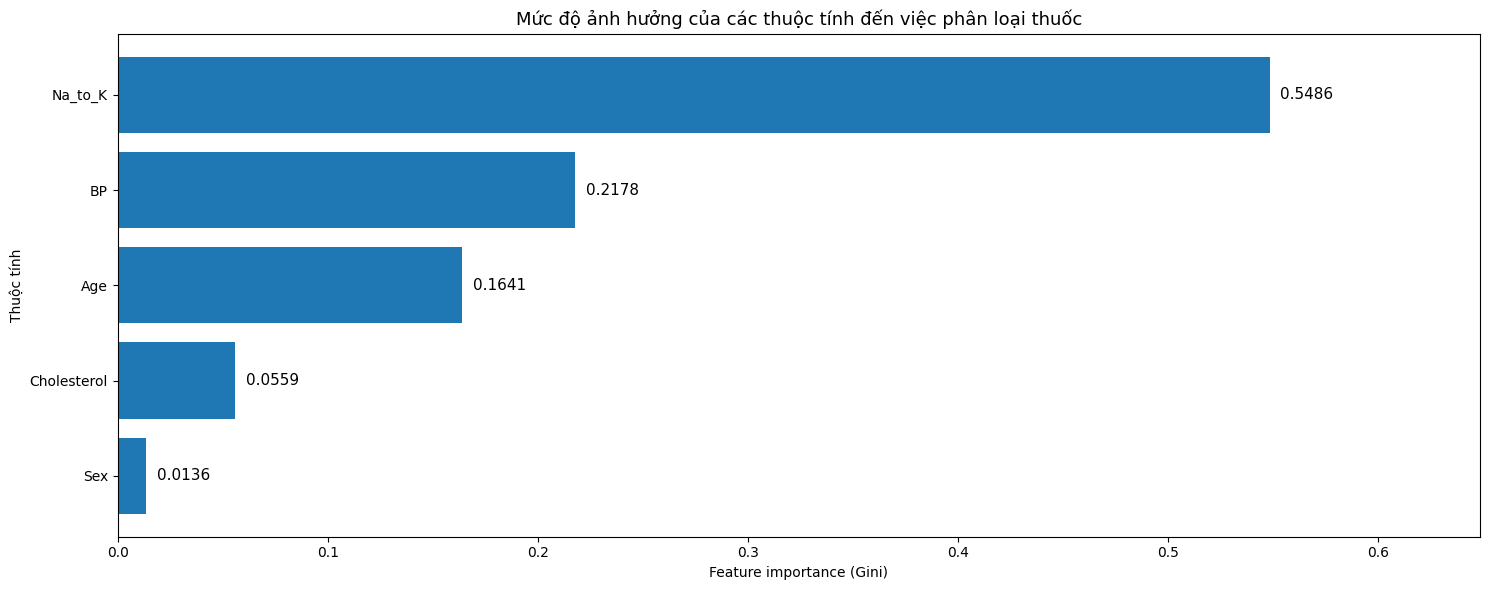

In [15]:
feature_names = ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']
importances = drugTree.feature_importances_

feat_df = pd.DataFrame({'Thuộc tính': feature_names, 'Mức độ ảnh hưởng': importances})
feat_df = feat_df.sort_values('Mức độ ảnh hưởng', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(15, 6))
bars = ax.barh(feat_df['Thuộc tính'], feat_df['Mức độ ảnh hưởng'])
for bar, val in zip(bars, feat_df['Mức độ ảnh hưởng']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=11)
ax.set_title('Mức độ ảnh hưởng của các thuộc tính đến việc phân loại thuốc', fontsize=13)
ax.set_xlabel('Feature importance (Gini)')
ax.set_ylabel('Thuộc tính')
ax.set_xlim(0, importances.max() + 0.1)
plt.tight_layout()
plt.show()

---
## 9. Lựa chọn tối ưu tham số

Chỉ dùng tập **train** để thực hiện lựa chọn tham số — tránh data leakage.

Sử dụng chiến lược **5-fold Cross Validation** kết hợp **GridSearchCV** để tìm bộ siêu tham số tốt nhất cho Random Forest:
- `n_estimators`: số lượng cây
- `max_depth`: độ sâu tối đa của mỗi cây
- `min_samples_split`: số mẫu tối thiểu để tách nút

In [16]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_trainset, y_trainset)

print('Tham số tốt nhất  :', grid_search.best_params_)
print(f'Accuracy CV tốt nhất: {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)')

Tham số tốt nhất  : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Accuracy CV tốt nhất: 0.9929 (99.29%)


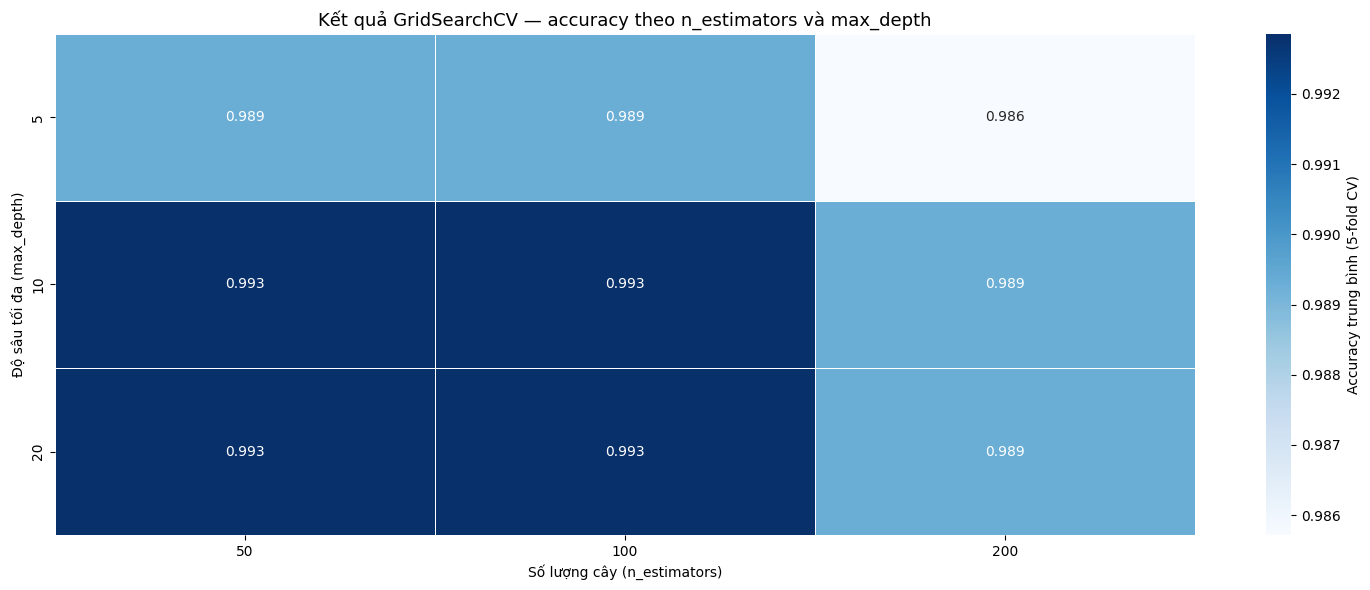

In [17]:
cv_results = pd.DataFrame(grid_search.cv_results_)
pivot = cv_results.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators'
)

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Accuracy trung bình (5-fold CV)'})
ax.set_title('Kết quả GridSearchCV — accuracy theo n_estimators và max_depth', fontsize=13)
ax.set_xlabel('Số lượng cây (n_estimators)')
ax.set_ylabel('Độ sâu tối đa (max_depth)')
plt.tight_layout()
plt.show()

In [18]:
best_rf = grid_search.best_estimator_
best_rf.fit(X_trainset, y_trainset)
pred_best_rf = best_rf.predict(X_testset)

acc_best = metrics.accuracy_score(y_testset, pred_best_rf)
print(f'Accuracy của Random Forest (tham số tối ưu) trên tập test: {acc_best:.4f} ({acc_best*100:.2f}%)')

Accuracy của Random Forest (tham số tối ưu) trên tập test: 0.9833 (98.33%)


---
## 10. So sánh các mô hình

Sau khi chọn được bộ tham số tốt nhất cho mỗi mô hình, huấn luyện lại trên toàn bộ tập train và đánh giá trên tập test.

So sánh 5 mô hình: Random Forest (tối ưu), Decision Tree, SVM, Neural Network (MLP), Logistic Regression.

In [19]:
models = {
    'Random Forest (tối ưu)': best_rf,
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

results_list = []
for name, model in models.items():
    if name != 'Random Forest (tối ưu)':
        model.fit(X_trainset, y_trainset)
    y_pred = model.predict(X_testset)
    results_list.append({
        'Mô hình': name,
        'Accuracy': metrics.accuracy_score(y_testset, y_pred),
        'Precision': metrics.precision_score(y_testset, y_pred, average='weighted'),
        'Recall': metrics.recall_score(y_testset, y_pred, average='weighted'),
        'F1-score': metrics.f1_score(y_testset, y_pred, average='weighted')
    })

results_df = pd.DataFrame(results_list).sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1

print('Bảng so sánh các mô hình (sắp xếp theo accuracy giảm dần):')
print(results_df.to_string(float_format='{:.4f}'.format))

Bảng so sánh các mô hình (sắp xếp theo accuracy giảm dần):
                  Mô hình  Accuracy  Precision  Recall  F1-score
1  Random Forest (tối ưu)    0.9833     0.9841  0.9833    0.9833
2           Decision Tree    0.9833     0.9841  0.9833    0.9833
3     Logistic Regression    0.9500     0.9574  0.9500    0.9510
4    Neural Network (MLP)    0.8833     0.8989  0.8833    0.8862
5                     SVM    0.7000     0.5227  0.7000    0.5933


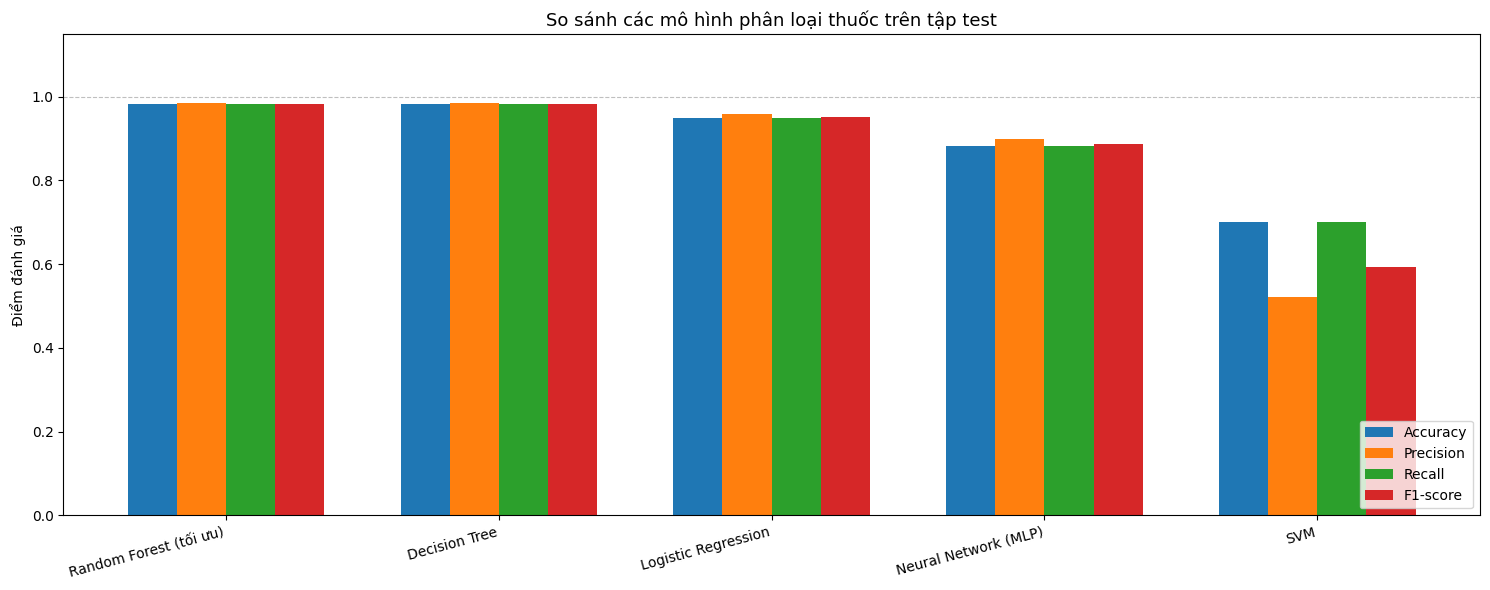

In [20]:
fig, ax = plt.subplots(figsize=(15, 6))

x = np.arange(len(results_df))
width = 0.18
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-score']

for i, col in enumerate(metric_cols):
    ax.bar(x + i * width, results_df[col], width, label=col)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Mô hình'], rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_title('So sánh các mô hình phân loại thuốc trên tập test', fontsize=13)
ax.set_ylabel('Điểm đánh giá')
ax.legend(loc='lower right')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
plt.tight_layout()
plt.show()

In [21]:
winner = results_df.iloc[0]
print('Mô hình tốt nhất:', winner['Mô hình'])
print(f'  Accuracy : {winner["Accuracy"]:.4f}')
print(f'  Precision: {winner["Precision"]:.4f}')
print(f'  Recall   : {winner["Recall"]:.4f}')
print(f'  F1-score : {winner["F1-score"]:.4f}')

Mô hình tốt nhất: Random Forest (tối ưu)
  Accuracy : 0.9833
  Precision: 0.9841
  Recall   : 0.9833
  F1-score : 0.9833


### Confusion matrix

Vẽ confusion matrix cho mô hình Random Forest (tham số tối ưu) — mô hình đạt kết quả tốt nhất.

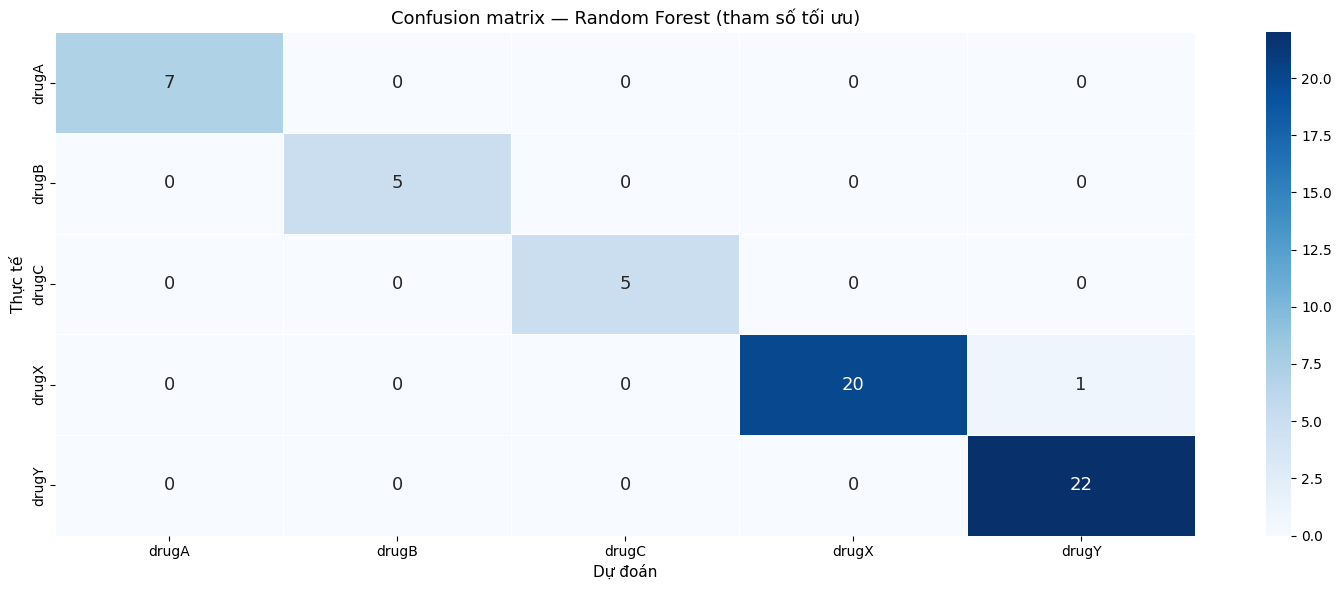

In [22]:
drug_classes = sorted(y.unique())
cm = confusion_matrix(y_testset, pred_best_rf, labels=drug_classes)

df_cm = pd.DataFrame(cm, index=drug_classes, columns=drug_classes)
df_cm.index.name = 'Thực tế'
df_cm.columns.name = 'Dự đoán'

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.5, annot_kws={'size': 13})
ax.set_title('Confusion matrix — Random Forest (tham số tối ưu)', fontsize=13)
ax.set_xlabel('Dự đoán', fontsize=11)
ax.set_ylabel('Thực tế', fontsize=11)
plt.tight_layout()
plt.show()

In [23]:
print('Báo cáo phân loại chi tiết — Random Forest (tham số tối ưu):')
print(classification_report(y_testset, pred_best_rf, target_names=drug_classes))

Báo cáo phân loại chi tiết — Random Forest (tham số tối ưu):
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.96      1.00      0.98        22

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60



---
## Kết luận

- Random Forest và Decision Tree đạt accuracy cao nhất (khoảng 98%) trên tập test. Random Forest ổn định hơn nhờ cơ chế ensemble giảm phương sai.
- Logistic Regression đạt khoảng 95%, phù hợp khi cần mô hình đơn giản, dễ giải thích.
- SVM và Neural Network (MLP) có accuracy thấp hơn trên bộ dữ liệu nhỏ này và cần điều chỉnh tham số kỹ hơn.
- Thuộc tính Na_to_K ảnh hưởng lớn nhất đến kết quả phân loại (khoảng 55%), tiếp theo là BP và Age.
- GridSearchCV 5-fold CV xác định bộ tham số tối ưu và đạt accuracy CV lên tới khoảng 99% trên tập train.